In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import time
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import string
import numpy as np
import tensorflow as tf
from keras.layers import (
    Dense,
    Convolution2D,
    MaxPooling2D,
    Flatten,
)
from keras.models import Sequential
from PIL import Image, ImageOps


In [2]:
RUSSIAN_WEIGHTS = "api/weights/comnist_keras_ru.hdf5"
TEST_DIR = "images/Cyrillic_test"
SIZE = 32
nb_classes = 34
batch_size = 32
img_height = 32
img_width = 32



In [3]:
# Load the datasets


# test_dataset = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR,
#     seed=123,
#     image_size=(img_height, img_width),
#     batch_size=batch_size,
#     labels="inferred",
# )

class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
name_to_index = {name: i for i, name in enumerate(class_names)}
print(class_names)
print(name_to_index)

['I', 'Ё', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ', 'Ы', 'Ь', 'Э', 'Ю', 'Я']
{'I': 0, 'Ё': 1, 'А': 2, 'Б': 3, 'В': 4, 'Г': 5, 'Д': 6, 'Е': 7, 'Ж': 8, 'З': 9, 'И': 10, 'Й': 11, 'К': 12, 'Л': 13, 'М': 14, 'Н': 15, 'О': 16, 'П': 17, 'Р': 18, 'С': 19, 'Т': 20, 'У': 21, 'Ф': 22, 'Х': 23, 'Ц': 24, 'Ч': 25, 'Ш': 26, 'Щ': 27, 'Ъ': 28, 'Ы': 29, 'Ь': 30, 'Э': 31, 'Ю': 32, 'Я': 33}


/home/aris/CoMNIST/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775579364.054109   20615 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775579364.377186   20615 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775579364.377306   20615 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1775579364.379992   20615 cuda_execu

Loaded weights from file api/weights/comnist_keras_ru.hdf5
Created model and loaded weights from file


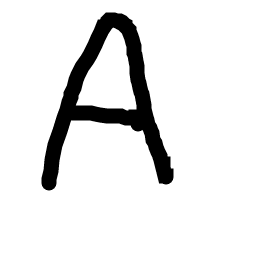

In [4]:
from api.model import load_letter_predictor
from IPython.display import display


commnist_predictor = load_letter_predictor(weight=RUSSIAN_WEIGHTS, nb_classes=34, lang_in="ru")
img_copy = Image.open("images/Cyrillic_test/А/5a2f3c19c27bb.png")
blank = Image.new("L", img_copy.size, color=255)
img_copy.paste(blank, (0, 0), mask=img_copy)
img_copy = img_copy.convert("L")
img_copy = ImageOps.invert(img_copy)
display(img_copy)


In [5]:
from api.image_proc import crop_letters


for i, letter in enumerate(crop_letters(img_copy)):
    predicted_letter = commnist_predictor(letter,1)
    print(f"Predicted letter: {predicted_letter}")

I0000 00:00:1775579366.708573   20729 service.cc:146] XLA service 0x7ef860006230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775579366.708659   20729 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1050 Ti, Compute Capability 6.1


Predicted letter: ['А']


I0000 00:00:1775579368.364208   20729 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [6]:
y_true = []
y_pred = []

for cls in class_names:
    folder = os.path.join(TEST_DIR, cls)
    for fn in os.listdir(folder):
        img_path = os.path.join(folder, fn)
        img = Image.open(img_path)

            # Add a white background to the image

        blank = Image.new("L", img.size, color=255)
        img.paste(blank, (0, 0), mask=img)
        img = img.convert("L")
        img = ImageOps.invert(img)

        # Get negative of image in case it is white on black
        # img_np = np.array(img)
        # if np.mean(img_np) < 128:
            
            
            
        pred_list = commnist_predictor(img, nb_output=1)   # returns list like ['Д']
        pred_char = pred_list[-1]
        # convert true/pred to integer class indices
        y_true.append(name_to_index[cls])
        # find predicted class index in class_names (ensure char == folder name)
        # if your folder names are letter characters use:
        y_pred.append(name_to_index.get(pred_char, -1))



In [8]:

len(y_true), len(y_pred)
print("Accuracy:", accuracy_score(y_true, y_pred)*100,"%")
print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)

Accuracy: 92.0188800686548 %
              precision    recall  f1-score   support

           I       1.00      1.00      1.00        75
           Ё       0.56      0.99      0.72       104
           А       1.00      0.96      0.98       141
           Б       0.93      0.96      0.95       134
           В       1.00      0.87      0.93       147
           Г       0.91      0.98      0.95       128
           Д       0.96      0.90      0.93       140
           Е       0.92      0.58      0.71       173
           Ж       0.99      0.91      0.95       139
           З       0.96      0.75      0.84       130
           И       1.00      0.79      0.88       135
           Й       0.87      0.99      0.93       140
           К       1.00      0.98      0.99       138
           Л       0.98      0.99      0.98       130
           М       0.98      0.96      0.97       141
           Н       0.96      0.99      0.97       153
           О       1.00      0.98      0.99       14